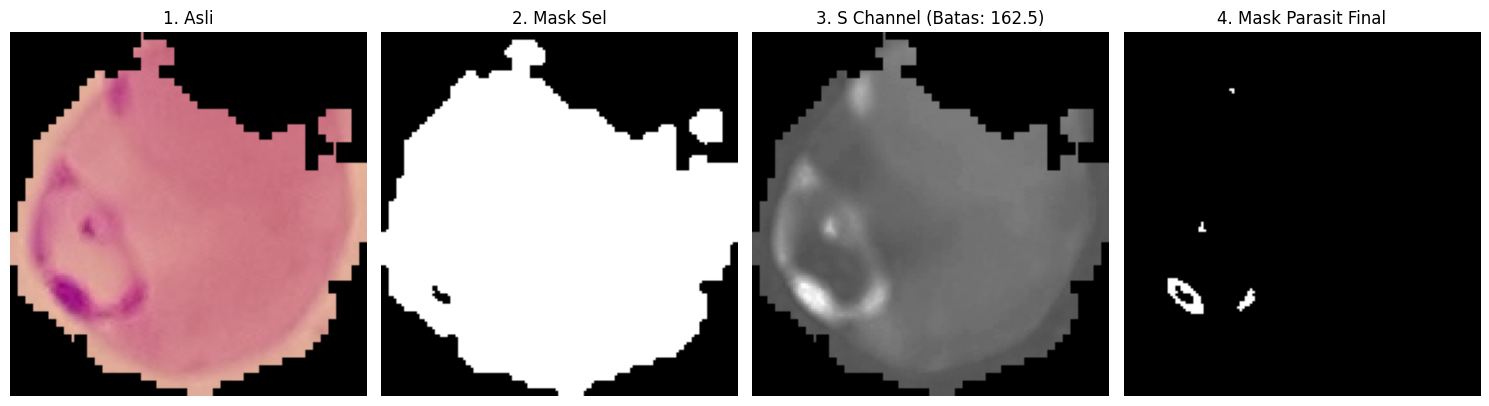

In [4]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt

# Ini harusnya dah oke
# image_path = '../data/Parasitized/C33P1thinF_IMG_20150619_120645a_cell_217.png' 

# ini jg oke 
# image_path = '../data/Parasitized/C33P1thinF_IMG_20150619_121229a_cell_178.png' 

# ini harusnya ada 3 parasit?
# image_path = '../data/Parasitized/C189P150ThinF_IMG_20151.png203_142113_cell_87.png'
image_path = '../data/Parasitized/C37BP2_thinF_IMG_20150620_133238a_cell_97.png'

# image_path = '../data/Parasitized/C39P4thinF_original_IMG_20150622_110352_cell_78.png'

# uninfected
# image_path = '../data/Uninfected/C1_thinF_IMG_20150604_104722_cell_73.png'
img_bgr = cv2.imread(image_path)

 
if img_bgr is None:
    print("image not found")
else:
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # --- MASKING 1: CARI BATAS SEL ---
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    ret_cell, thresh_cell = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    mask_cell = cv2.bitwise_not(thresh_cell) 

    # --- MASKING 2: STATISTICAL THRESHOLD (DIPERKETAT) ---
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv) 
    
    s_inside_cell = s[mask_cell == 255]
    
    if len(s_inside_cell) == 0:
        # Handle kasus kalo mask_cell kosong (gambar hitam semua)
        mask_parasite_final = np.zeros_like(s)
        print("Peringatan: Tidak ada sel terdeteksi.")
    else:
        mean_s = np.mean(s_inside_cell)
        std_s = np.std(s_inside_cell)
        
        # --- PERUBAHAN DI SINI ---
        # Naikkan dari 2 menjadi 3 (3 sigma rule). Lebih ketat.
        # Ditambah sedikit konstanta (+10) agar jika sel sangat seragam,
        # noise kecil tidak langsung dianggap parasit.
        batas_parasit = mean_s + (3 * std_s) + 10
        
        _, mask_parasite_raw = cv2.threshold(s, batas_parasit, 255, cv2.THRESH_BINARY)
        mask_parasite_final = cv2.bitwise_and(mask_parasite_raw, mask_cell)
    
    # VISUALISASI PREPROCESSING
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 4, 1); plt.imshow(img_rgb); plt.title('1. Asli'); plt.axis('off')
    plt.subplot(1, 4, 2); plt.imshow(mask_cell, cmap='gray'); plt.title('2. Mask Sel'); plt.axis('off')
    plt.subplot(1, 4, 3); plt.imshow(s, cmap='gray'); plt.title(f'3. S Channel (Batas: {batas_parasit:.1f})'); plt.axis('off')
    plt.subplot(1, 4, 4); plt.imshow(mask_parasite_final, cmap='gray'); plt.title('4. Mask Parasit Final'); plt.axis('off')
    plt.tight_layout(); plt.show()

--- HASIL EKSTRAKSI FITUR FINAL ---
Luas Area Sel       : 12382.5 pixels
Jumlah Parasit      : 1
Total Luas Parasit  : 99.5 pixels


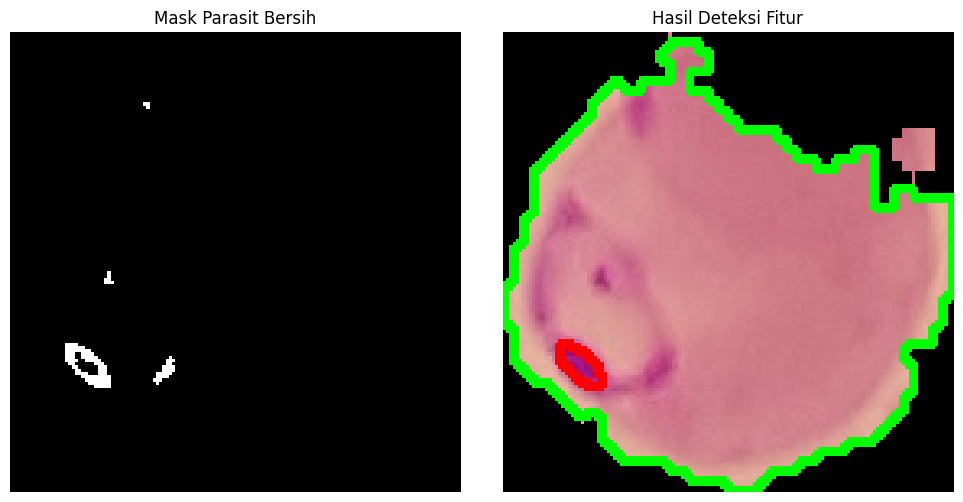

In [5]:
 # --- CARI CONTOURS ---
contours_cell, _ = cv2.findContours(mask_cell, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours_parasite, _ = cv2.findContours(mask_parasite_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_result = img_rgb.copy()
cell_area = 0
parasite_area = 0
parasite_count = 0

# 1. Hitung Luas Sel
for cnt in contours_cell:
    area = cv2.contourArea(cnt)
    if area > 500: 
        cell_area += area
        cv2.drawContours(img_result, [cnt], -1, (0, 255, 0), 2) 

# 2. Hitung Parasit
for cnt in contours_parasite:
    area = cv2.contourArea(cnt)
    # --- PERUBAHAN DI SINI ---
    # Naikkan filter area dari 10 menjadi 25 piksel.
    # Ini untuk mengabaikan noise kecil seperti yang ada di bawah gambar sehat tadi.
    if area > 25: 
        parasite_area += area
        parasite_count += 1
        cv2.drawContours(img_result, [cnt], -1, (255, 0, 0), 2) 

print(f"--- HASIL EKSTRAKSI FITUR FINAL ---")
print(f"Luas Area Sel       : {cell_area} pixels")
print(f"Jumlah Parasit      : {parasite_count}")
print(f"Total Luas Parasit  : {parasite_area} pixels")

# VISUALISASI HASIL AKHIR
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(mask_parasite_final, cmap='gray'); plt.title('Mask Parasit Bersih'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_result); plt.title('Hasil Deteksi Fitur'); plt.axis('off')
plt.tight_layout(); plt.show()